In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import cv2
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

In [2]:
# Create empty lists to store the features and labels
X = []
Y = []

flower_daisy = os.listdir('Flowers/flowers/daisy')
flower_dandelion = os.listdir('Flowers/flowers/dandelion')
flower_rose = os.listdir('Flowers/flowers/rose')
flower_sunflower = os.listdir('Flowers/flowers/sunflower')
flower_tulip = os.listdir('Flowers/flowers/tulip')

In [3]:
print('Number of daisy images: ', len(flower_daisy))
print('Number of dandelion images: ', len(flower_dandelion))
print('Number of rose images: ', len(flower_rose))
print('Number of sunflower images: ', len(flower_sunflower))
print('Number of tulip images: ', len(flower_tulip))

Number of daisy images:  764
Number of dandelion images:  1052
Number of rose images:  784
Number of sunflower images:  733
Number of tulip images:  984


In [5]:
# Function to assign labels to the images based on the flower type
def assign_label(img, flower_type):
    return flower_type

In [6]:
def make_train_data(flower_type, DIR):
    # Loop through the images in the directory and assign labels
    for img in tqdm(os.listdir(DIR)):
        label = assign_label(img, flower_type)
        path = os.path.join(DIR, img)

        # Read the image using OpenCV
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (100, 100))  # Resize the image to a fixed size

        # Append the image and label to the lists
        X.append(np.array(img))
        Y.append(str(label))


Train all Flower Types

In [7]:
make_train_data('Daisy', 'Flowers/flowers/daisy')
print(len(X))

100%|██████████| 764/764 [00:00<00:00, 1036.92it/s]

764


In [8]:
make_train_data('Dandelion', 'Flowers/flowers/dandelion')
print(len(X))


100%|██████████| 1052/1052 [00:01<00:00, 1044.63it/s]

1816


In [9]:
make_train_data('Sunflower', 'Flowers/flowers/sunflower')
print(len(X))

100%|██████████| 733/733 [00:00<00:00, 859.28it/s]

2549


In [10]:
make_train_data('Rose', 'Flowers/flowers/rose')
print(len(X))

100%|██████████| 784/784 [00:00<00:00, 1035.16it/s]

3333


In [11]:
make_train_data('Tulip', 'Flowers/flowers/tulip')
print(len(X))

100%|██████████| 984/984 [00:01<00:00, 941.96it/s] 

4317


In [12]:
# Label encoding the target variable (Tulip, Rose, Sunflower, Dandelion, Daisy into 0, 1, 2, 3, 4)
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

# Convert the labels to categorical format
Y = to_categorical(Y, num_classes=5)

# Convert the features and labels to numpy arrays
X = np.array(X)
X = X / 255.0  # Normalize the pixel values to [0, 1]

In [13]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


x_train shape:  (3453, 100, 100, 3)
x_test shape:  (864, 100, 100, 3)
y_train shape:  (3453, 5)
y_test shape:  (864, 5)


In [16]:
# The MLP should have at least 2
# hidden layers, and you can choose the number of neurons in each layer. You should use cross-
# entropy loss function, stochastic gradient descent optimization algorithm with a learning rate of
# 0.01.

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
 
# Build the CNN model Input → Layer 1 → Layer 2 → Layer 3 → Output

# Empty model
model = Sequential()

# Adding the first convolutional layer with 32 filters, kernel size of 5x5 (Part of the Picture), 'Same' padding(The output should remain approximately the same size as the input )
# and ReLU activation function. 
# The input shape is set to (150, 150, 3) for RGB images.
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                    activation ='relu', input_shape = (100,100,3)))
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same',
                    activation ='relu'))

# Adding a max pooling layer with a pool size of 2x2 to reduce the spatial dimensions of the feature maps.
model.add(MaxPool2D(pool_size=(2,2)))

# Adding a dropout layer with a rate of 0.25 to prevent overfitting by randomly setting 25% of the input units to 0 during training.
model.add(Dropout(0.25))

# Adding the second convolutional layer with 64 filters, kernel size of 3x3, 'Same' padding, and ReLU activation function.
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                    activation ='relu'))
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same',
                    activation ='relu'))

model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

# Adding a flatten layer to convert the 2D feature maps into a 1D feature vector, which can be fed into the fully connected layers.
model.add(Flatten())

# Adding a fully connected layer with 256 neurons and ReLU activation function.
model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(5, activation = "softmax"))
 
# Compile the model using the Adam optimizer, categorical cross-entropy loss function, and accuracy as the evaluation metric.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
 
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 100, 100, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,240,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,325,029 (39.39 MB)

 Trainable params: 10,325,029 (39.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step - accuracy: 0.2470 - loss: 1.6066 - val_accuracy: 0.3310 - val_loss: 1.4898
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.3383 - loss: 1.4190 - val_accuracy: 0.4653 - val_loss: 1.3745
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.4758 - loss: 1.2621 - val_accuracy: 0.5394 - val_loss: 1.1978
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 173ms/step - accuracy: 0.5361 - loss: 1.1380 - val_accuracy: 0.5868 - val_loss: 1.0641
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.5908 - loss: 1.0446 - val_accuracy: 0.6343 - val_loss: 0.9840
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - accuracy: 0.6629 - loss: 0.9023 - val_accuracy: 0.6250 - val_loss: 0.9671
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.6965 - loss: 0.8005 - val_accuracy: 0.6134 - val_loss: 1.0645
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.7344 - loss: 0

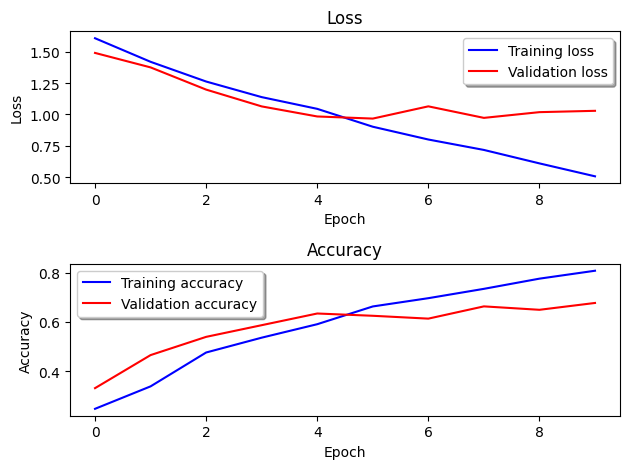

In [18]:
# Plot the loss and accuracy curves for training and validation
fig, ax = plt.subplots(2, 1)

ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation loss")
ax[0].legend(loc='best', shadow=True)
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].legend(loc='best', shadow=True)
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [19]:
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)


Evaluate on test data
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.6771 - loss: 1.0289
test loss, test acc: [1.0289191007614136, 0.6770833134651184]


In [20]:
# print classification report

# Predict the classes for the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred,axis = 1)
y_true = np.argmax(y_test,axis = 1)
print(classification_report(y_true, y_pred_classes))
 

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
              precision    recall  f1-score   support

           0       0.71      0.76      0.73       162
           1       0.67      0.80      0.73       223
           2       0.61      0.47      0.53       146
           3       0.72      0.73      0.72       144
           4       0.66      0.59      0.62       189

    accuracy                           0.68       864
   macro avg       0.67      0.67      0.67       864
weighted avg       0.67      0.68      0.67       864



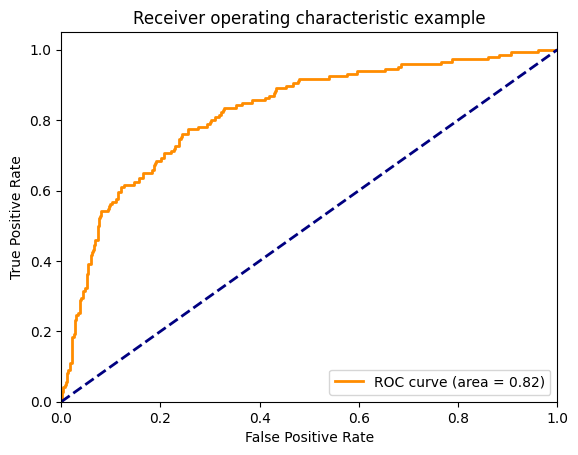

In [21]:
# plot roc curve
fpr = dict() # False Positive Rate
tpr = dict() # True Positive Rate
roc_auc = dict() 
for i in range(5):
    # Compute ROC curve and ROC area for each class
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
     
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
 
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
            lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

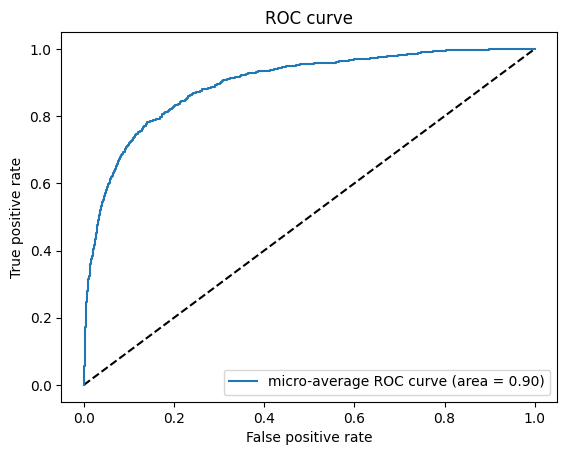

In [22]:
# plot auc curve
plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr["micro"], tpr["micro"], label='micro-average ROC curve (area = {0:0.2f})'
                                        ''.format(roc_auc["micro"]))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()